In [41]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import json

In [24]:
model_name = "resnet18"

In [44]:
main_path = Path("../../jetson/power_logging/raw_data") / model_name
ablated_paths = [path for path in main_path.iterdir() if path.is_dir() and path.name.startswith("ablate")]
log_name = f"{model_name}_power_log.log"

In [26]:
main_df = pd.read_csv(main_path / log_name, names=["time", "voltage", "current"], parse_dates=[0])
ablated_dfs = {path.name: pd.read_csv(path / log_name, names=["time", "voltage", "current"], parse_dates=[0]) for path in ablated_paths if (path / log_name).exists()}

In [49]:
def read_latency(path: Path):
    fullpath = path / "trt_profiling" / "trt_layer_latency.json"
    with open(fullpath) as f:
        return json.load(f)

def get_time_bounds(latency):
    layers = list(latency.values())
    return pd.to_datetime(layers[0][0][1]), pd.to_datetime(layers[-1][-1][1])

In [51]:
main_latency = read_latency(main_path)
ablated_latencies = {path.name: read_latency(path) for path in ablated_paths}

In [55]:
def cut_active_df(df, latency):
    min_time, max_time = get_time_bounds(latency)
    return df[(df.time >= min_time) & (df.time <= max_time)].reset_index(drop=True)

In [53]:
idle_power = 4148813.0

main_df["power"] = main_df.current * main_df.voltage - idle_power
for df in ablated_dfs.values():
    df["power"] = df.current * df.voltage - idle_power



# Data analysis

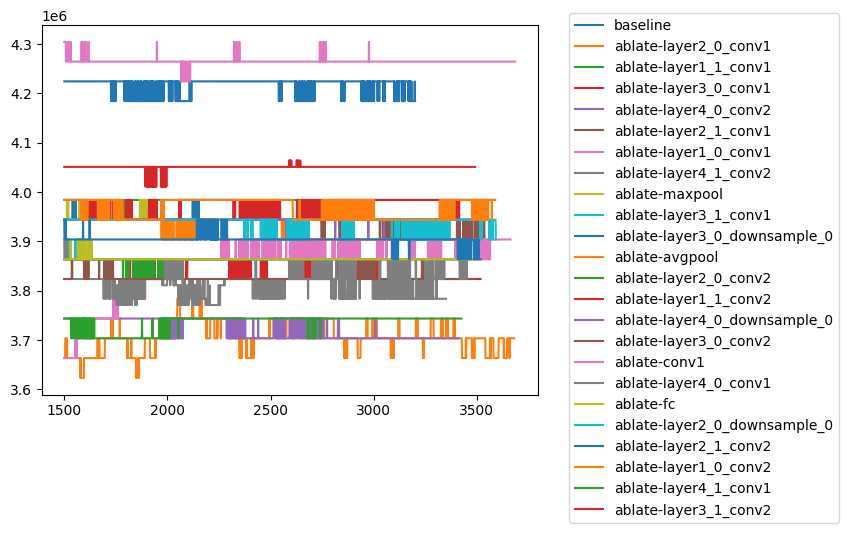

In [57]:
a = 0 # 39000
b = -1 # 75000

cut_active_df(main_df, main_latency).iloc[1500:].power.plot(label="baseline")
for key, df in ablated_dfs.items():
    cut_active_df(df, ablated_latencies[key]).iloc[1500:].power.plot(label=key)
    
plt.legend(bbox_to_anchor=(1.05, 1.05))
plt.show()

Observations:
* There's definitely a difference between the baseline and ablated networks in terms of power draw
* However, ablate-conv1 network draws more power, which suggests that ablation may not be performed correctly

In [58]:
stats = {"baseline": cut_active_df(main_df, main_latency).iloc[1500:].power.describe()}
for key, df in ablated_dfs.items():
    stats[key] = cut_active_df(df, ablated_latencies[key]).iloc[1500:].power.describe()

stats_df = pd.DataFrame(stats).T

In [59]:
stats_df

,count,mean,std,min,25%,50%,75%,max
baseline,1702.0,4.214935e+06,17123.135326,4184499.0,4224563.0,4224563.0,4224563.0,4224563.0
ablate-layer2_0_conv1,2182.0,3.704190e+06,28872.641954,3623603.0,3703731.0,3703731.0,3703731.0,3783859.0
ablate-layer1_1_conv1,2090.0,3.983853e+06,3599.449260,3944115.0,3984179.0,3984179.0,3984179.0,3984179.0
ablate-layer3_0_conv1,2019.0,3.840433e+06,19724.799138,3823923.0,3823923.0,3823923.0,3863987.0,3863987.0
ablate-layer4_0_conv2,1913.0,3.722433e+06,19993.033493,3703731.0,3703731.0,3703731.0,3743795.0,3743795.0
ablate-layer2_1_conv1,2040.0,3.937929e+06,14480.395946,3904051.0,3944115.0,3944115.0,3944115.0,3944115.0
ablate-layer1_0_conv1,2164.0,3.855174e+06,61671.653303,3663667.0,3863987.0,3863987.0,3904051.0,3904051.0
ablate-layer4_1_conv2,1852.0,3.808631e+06,19999.858506,3771187.0,3783859.0,3823923.0,3823923.0,3823923.0
ablate-maxpool,2064.0,3.945260e+06,6677.794360,3944115.0,3944115.0,3944115.0,3944115.0,3984179.0
ablate-layer3_1_conv1,1989.0,3.864188e+06,2834.337891,3863987.0,3863987.0,3863987.0,3863987.0,3904051.0


In [62]:
median_difference = stats_df["50%"].baseline - stats_df["50%"]
median_difference[median_difference < 0.0] = 0.0
median_difference

baseline                             0.0
ablate-layer2_0_conv1           520832.0
ablate-layer1_1_conv1           240384.0
ablate-layer3_0_conv1           400640.0
ablate-layer4_0_conv2           520832.0
ablate-layer2_1_conv1           280448.0
ablate-layer1_0_conv1           360576.0
ablate-layer4_1_conv2           400640.0
ablate-maxpool                  280448.0
ablate-layer3_1_conv1           360576.0
ablate-layer3_0_downsample_0    280448.0
ablate-avgpool                  280448.0
ablate-layer2_0_conv2           360576.0
ablate-layer1_1_conv2           240384.0
ablate-layer4_0_downsample_0    280448.0
ablate-layer3_0_conv2           400640.0
ablate-conv1                         0.0
ablate-layer4_0_conv1           360576.0
ablate-fc                       360576.0
ablate-layer2_0_downsample_0    280448.0
ablate-layer2_1_conv2           320512.0
ablate-layer1_0_conv2           240384.0
ablate-layer4_1_conv1           480768.0
ablate-layer3_1_conv2           173376.0
Name: 50%, dtype

Observations:


In [71]:
unexplained = stats_df["50%"].baseline - median_difference.sum()
# unexplained = 0.0

In [72]:
unexplained / stats_df["50%"].baseline

np.float64(-0.7575687710184462)

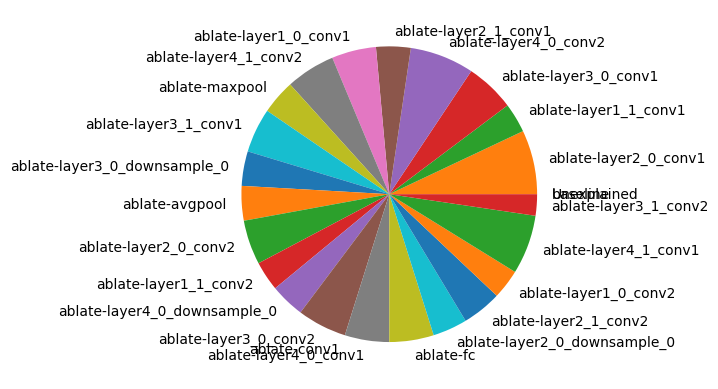

In [70]:
plt.pie(list(median_difference.values) + [unexplained], labels = list(median_difference.index) + ["Unexplained"])
plt.show()

Similar conclusions about ablation being incorrect can be drawn here, as the total reduction in power draw is nowhere near the total power consumption.